### Легенда
В контакт-центре внедрили новый скрипт разговора для операторов.
### Цель — повысить FCR (решение с первого звонка) и снизить AHT (время разговора).
### Данные:
Вы провели A/B-тест в течение 14 дней.
Группа A (контроль) — старый скрипт
Группа B (тест) — новый скрипт
### Тебе нужно:
1. Проверить, есть ли статистически значимое улучшение
2. Оценить размер эффекта (на сколько % вырос FCR, снизился AHT)
3. Понять, стоило ли внедрять изменение (экономический эффект)
4. Дать рекомендацию — внедрять или нет

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency,ttest_ind,shapiro,mannwhitneyu,chisquare
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms

## Чтение и первичный осмотр данных

In [2]:
df = pd.read_csv(r'data/ab_test_results.csv')
print(f'Колличество строк :{df.shape[0]} \nКолличество столбцов :{df.shape[1]}')
df.head(5)

Колличество строк :2000 
Колличество столбцов :7


,date,hour,group,operator_experience,fcr,aht_sec,day_of_week
0,2026-08-07,8,B,middle,1,303.0,4
1,2026-08-04,14,A,senior,0,324.0,1
2,2026-08-13,15,B,middle,1,335.0,3
3,2026-08-11,10,B,senior,1,299.0,1
4,2026-08-08,10,A,junior,1,347.0,5


## Проверить группы А и Б на сбалансированность по:
- [x] Датам
- [ ] Часам
- [ ] Группам
- [x] Грейдам
- [x] FCR
- [ ] AHT
- [ ] Дням недели

In [3]:
# 1. Строим правильную таблицу: сколько звонков закрыто в 0 и в 1
fcr_counts = df.pivot_table(
    index='group',
    columns='fcr',      # Разделяем на столбцы: 0 (не решено) и 1 (решено)
    values='date',     # Берем любой столбец для подсчета строк
    aggfunc='count'     # Считаем именно ШТУКИ, а не среднее
)
# 2. Теперь передаем таблицу «штук» в тест Хи-квадрат
chi2, p_value, dof, expected = chi2_contingency(fcr_counts)
print(f"\np-value для FCR: {p_value}")


p-value для FCR: 0.06714367374922825


In [4]:
aht_mean = df.pivot_table(
    index='group',
    values='aht_sec',
    aggfunc='mean'  
)
aht_mean

,aht_sec
group,
A,311.318321
B,295.169110


In [5]:
group_A_seconds = df[df['group']=='A']['aht_sec']
group_B_seconds = df[df['group']=='B']['aht_sec']

t_stas, p_value_aht = ttest_ind(group_A_seconds,group_B_seconds)

In [6]:
t_stas

np.float64(10.370534713068196)

In [7]:
p_value_aht

np.float64(1.4016318762936357e-24)

# Значение меньше 0.05. Различия не случайны

## Загрузка данных и проверка баланса групп
- [x] по количеству наблюдений
- [x] по дням недели
- [x] по опыту(грейду сотрудников)
- [x] по часам
- [x] по датам

In [8]:
# Проверка распределния по количеству наблюдений
print(50*'=')
print('Сбалансированность групп по колличеству наблюдений'.center(50))
print(50*'-')
print(df['group'].value_counts(normalize=True).round(4) * 100)
# Проверка распределение через однофакторный Хи-тест
counts = df['group'].value_counts()
stat, p_value = chisquare(counts)
print(50*'=')
print('Хи тест на кол-во наблюдений'.center(50))
print(50*'-')
print(f"p-value проверки деления выборки: {p_value:.2f}")


# Поверка распределения по дням недели
pivot_day_of_week = df.pivot_table(
    index='group',
    columns='day_of_week',
    values='operator_experience',
    aggfunc='count'
)
pivot_day_of_week
# Проверка баланса по дням недели черех Хи тест (таблица сопряженности)
chi2, p_value, dof, expected = chi2_contingency(pivot_day_of_week)
print(50*'=')
print('Хи тест по дням недели'.center(50))
print(50*'-')
print(f"p-value для дней недели: {p_value:.2f}")


# Проверяем сбалансированность групп по Грейдам сотрудников
operator_experience = df.pivot_table(
    index='group',
    columns='operator_experience',
    values='date',
    aggfunc='count'
)
chi2, p_value, dof, expected = chi2_contingency(operator_experience)
print(50*'=')
print('Хи тест по грейдам'.center(50))
print(50*'-')
print(f"p-value для грейдов: {p_value:.2f}")


# Проверяем сбалансированность групп по часам
operator_experience = df.pivot_table(
    index='group',
    columns='hour',
    values='date',
    aggfunc='count'
)
chi2, p_value, dof, expected = chi2_contingency(operator_experience)
print(50*'=')
print('Хи тест по часам'.center(50))
print(50*'-')
print(f"p-value для часов: {p_value:.2f}")


# Проверяем сбалансированность групп по датам
date_group = df.pivot_table(
    index='group',
    columns='date',
    values='hour',
    aggfunc='count'
)

chi2, p_value, dof, expected = chi2_contingency(date_group)

print(50*'=')
print('Хи тест по датам'.center(50))
print(50*'-')
print(f"p-value для дат: {p_value:.2f}")

Сбалансированность групп по колличеству наблюдений
--------------------------------------------------
group
B    51.15
A    48.85
Name: proportion, dtype: float64
           Хи тест на кол-во наблюдений           
--------------------------------------------------
p-value проверки деления выборки: 0.30
              Хи тест по дням недели              
--------------------------------------------------
p-value для дней недели: 0.86
                Хи тест по грейдам                
--------------------------------------------------
p-value для грейдов: 0.64
                 Хи тест по часам                 
--------------------------------------------------
p-value для часов: 0.15
                 Хи тест по датам                 
--------------------------------------------------
p-value для дат: 0.69


### Вывод:
P-value для всех проверенных параметров (количество наблюдений, распределение по дням недели, датам, грейдам сотрудников и часам) больше 0.05. Это строго доказывает, что сплитование выборки произведено равномерно, а группы А и Б идеально сбалансированы для проведения А/Б-теста.

## Описательная статитика и визуализация

Описательная статистика по группам:
        fcr              aht_sec              
       mean median   std    mean median    std
group                                         
A      0.63    1.0  0.48  311.32  310.0  34.98
B      0.67    1.0  0.47  295.17  296.0  34.65


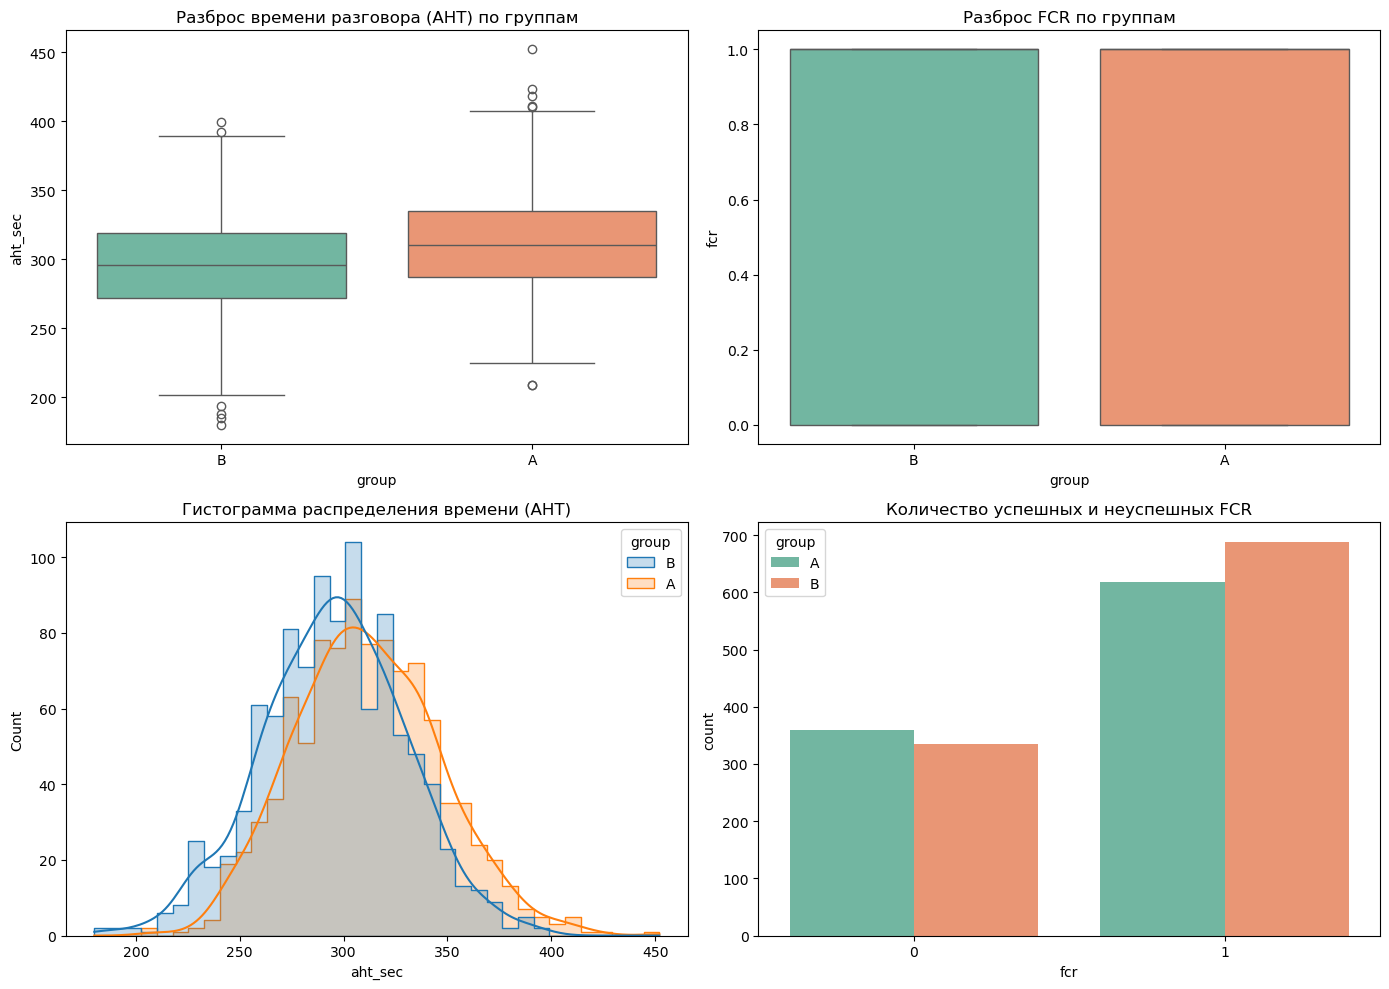

In [9]:
# Считаем среднее,медиану,стандартное отклонение по группам
eda_stats = df.groupby('group').agg({
    'fcr': ['mean','median','std'],
    'aht_sec':['mean','median','std']
}).round(2)
print("Описательная статистика по группам:")
print(eda_stats)

# Настраиваем окно для 4 графиков (2х2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot для AHT — ТЕПЕРЬ БЕЗ ПРЕДУПРЕЖДЕНИЙ
sns.boxplot(data=df, x='group', y='aht_sec', hue='group',ax=axes[0, 0], palette='Set2', legend=False)
axes[0, 0].set_title('Разброс времени разговора (AHT) по группам')

# 2. Boxplot для FCR — ТЕПЕРЬ БЕЗ ПРЕДУПРЕЖДЕНИЙ
sns.boxplot(data=df, x='group', y='fcr', hue='group', ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('Разброс FCR по группам')

# 3. Гистограмма распределения AHT
sns.histplot(data=df, x='aht_sec', hue='group', kde=True, ax=axes[1, 0], element='step', common_norm=False)
axes[1, 0].set_title('Гистограмма распределения времени (AHT)')

# 4. Гистограмма распределения FCR
sns.countplot(data=df, x='fcr', hue='group', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Количество успешных и неуспешных FCR')

plt.tight_layout()
plt.show()

### Вывод по блоку «Описательная статистика и визуализация»

Перед тем как запускать статистические тесты, просматриваем графики и рассчитал базовые показатели (среднее и медиану). Результаты:

1. **Метрика качества решения (FCR):**
   * В контрольной группе А (старый скрипт) средний FCR равен **63%**, а в целевой группе B (новый скрипт) — **67%**. Разница составляет **4 процентных пункта** в пользу нового скрипта.
   * На графике (countplot) визуально видно, что у группы B успешных звонков (единиц) чуть больше, а неуспешных (нулей) — меньше. На первый взгляд кажется, что новый скрипт помогает решать вопросы лучше, но эту разницу еще нужно проверить тестом на случайность.
   * *Примечание:* Медиана в обеих группах равна 1.0, а стандартное отклонение примерно одинаковое (~0.47), так как метрика состоит только из нулей и единиц, и эти показатели здесь не дают важной информации.

2. **Метрика времени разговора (AHT):**
   * Новый скрипт заметно снизил время диалога. В среднем операторы группы B говорят быстрее на **16,15 секунд** (295,17 сек против 311,32 сек в группе А).
   * Если смотреть на медиану (время «типичного» звонка), то группа B также быстрее группы А на **14 секунд** (296 сек против 310 сек). Это доказывает, что ускорение произошло по всей группе, а не из-за пары случайных операторов.
   * Стандартное отклонение (разброс данных) в обеих группах почти одинаковое (около 35 секунд). Это значит, что рамки звонков остались прежними — скрипт равномерно ускорил всех, не вызвав хаоса на линии.
   * На графиках (boxplot и гистограмма) четко видно, что весь синий «колокол» группы B сместился влево (в сторону быстрых звонков). Также у группы B появилось больше аномально коротких звонков (меньше 200 сек), а у группы А, наоборот, чаще зависали долгие разговоры (дольше 400 сек).

**Итог:** Первичный анализ показывает, что новый скрипт предварительно выполняет обе задачи: операторы стали говорить быстрее, и есть намек на улучшение качества работы. Перехожу к проверке гипотез через p-value, чтобы исключить случайность.


## ФОРМУЛИРОВКА ГИПОТЕЗ

Перед запуском статистических тестов я сформулировал Нулевые ($H_0$) и Альтернативные ($H_1$) гипотезы для каждой метрики.

#### 1. Метрика качества решения (FCR)
*   **$H_0$ FCR в A и B одинаков.**
*   **$H_1$ FCR в A и B различается.**

#### 2. Метрика времени разговора (AHT)
*   **$H_0$ распределение/средний уровень AHT в A и B не отличается.**
*   **$H_1$ AHT в A и B отличается.**

## ВЫБОР ТЕСТА И ПРОВЕРКА НА НОРМАЛЬНОСТЬ

In [10]:
print(50*'=')
print('Проводим тест Шапиро'.center(50))

# Вытаскиваем секунды
group_A_seconds = df[df['group'] == 'A']['aht_sec']
group_B_seconds = df[df['group'] == 'B']['aht_sec']
total_group     = df['aht_sec']

# Проверяем распределение AHT через тест Шапиро
stat_A, p_value_shapiro_A = shapiro(group_A_seconds)
print(f"p-value для группы А: {p_value_shapiro_A}")
stat_B, p_value_shapiro_B = shapiro(group_B_seconds)
print(f"p-value для группы B: {p_value_shapiro_B}")
stat_total, p_value_shapiro_total = shapiro(total_group)
print(f"p-value для всех групп: {p_value_shapiro_total}")

print(50*'=')
print('Проводим тест Манна-Уитни'.center(50))
# Запускаем тест Манна-Уитни (он устойчив к выбросам)
u_stat,p_value_mw = mannwhitneyu(group_A_seconds,group_B_seconds, alternative='two-sided')
print(f"p-value теста Манна-Уитни для AHT: {p_value_mw}")

               Проводим тест Шапиро               
p-value для группы А: 0.012181829002660195
p-value для группы B: 0.47340616608745123
p-value для всех групп: 0.3072904358266658
            Проводим тест Манна-Уитни             
p-value теста Манна-Уитни для AHT: 2.658157648289571e-21


### Вывод:

#### 1. Метрика качества решения (FCR)
*   **Выбор теста:** Для метрики FCR тест Шапиро-Уилка на нормальность не проводится. Так как эта метрика состоит только из нулей и единиц, у неё физически не может быть формы «колокола». По правилам аналитики для таких бинарных данных всегда используется **тест Хи-квадрат (таблица сопряженности)**.

#### 2. Метрика времени разговора (AHT)
Чтобы выбрать между Т-тестом и тестом Манна-Уитни, я запустил тест Шапиро-Уилка для времени звонков. Вот что получилось:
*   **Группа B:** `p-value = 0.47` (больше 0.05) — данные распределены нормально (идеальный колокол).
*   **Группа А:** `p-value = 0.01` (меньше 0.05) — **распределение отклонилось от нормы**.

**Почему так произошло:** 
Как мы уже видели на графике boxplot, в группе А есть «тяжелый хвост» из аномально долгих звонков (более 400 секунд). Тест Шапиро-Уилка очень чувствителен к таким единичным выбросам и поэтому показал, что распределение группы А не является идеально нормальным.

**Итоговый выбор теста для AHT:**
Так как распределение в группе А нарушено из-за затяжных звонков, классический Т-тест может сработать некорректно. Я выбираю **тест Манна-Уитни (U-test)**. Этот тест устойчив к выбросам, он сравнивает не сами средние значения, а ранги (места звонков в общей очереди), поэтому аномально долгие разговоры не исказят его результат.

#### Результат теста Манна-Уитни для AHT:
*   Компьютер выдал `p-value = 2.65e-21` (это число с 20 нулями после запятой: `0.0000...`). 
*   Этот результат **критически меньше, чем порог 0.05**. 
*   **Вывод:** Мы уверенно отвергаем нулевую гипотезу. Разница во времени разговора между группами А и Б огромна, абсолютно реальна и не вызвана случайным шумом. Новый скрипт действительно существенно изменил скорость работы операторов.


## РАСЧЁТ И ИНТЕРПРЕТАЦИЯ

In [11]:
# Проведение теста по группам для FCR
fcr_counts = df.pivot_table(
    index='group',
    columns='fcr',
    values='date',
    aggfunc='count'
)

chi2, p_value_fcr, dof, expected = chi2_contingency(fcr_counts)
print(f"\np-value для FCR: {p_value}")


# Проведение теста по группам для AHT 
group_A_seconds = df[df['group']=='A']['aht_sec']
group_B_seconds = df[df['group']=='B']['aht_sec']

res_aht = ttest_ind(group_A_seconds,group_B_seconds, equal_var=False)
p_value_aht = float(res_aht.pvalue)

ci_aht = res_aht.confidence_interval(confidence_level=0.95)

# Выводим все цифры на экран
print(50*'=')
print(f"FCR p-value: {p_value_fcr:.4f}")
print(50*'=')
print(f"AHT p-value: {p_value_aht}")  # Выведется в формате с буквой 'e'
print(f"95% Доверительный интервал для разницы AHT: от {ci_aht.low:.2f} до {ci_aht.high:.2f} сек.")
print(50*'=')


p-value для FCR: 0.6875073508998734
FCR p-value: 0.0671
AHT p-value: 1.4396470042086383e-24
95% Доверительный интервал для разницы AHT: от 13.09 до 19.20 сек.


In [12]:
df

,date,hour,group,operator_experience,fcr,aht_sec,day_of_week
0,2026-08-07,8,B,middle,1,303.0,4
1,2026-08-04,14,A,senior,0,324.0,1
2,2026-08-13,15,B,middle,1,335.0,3
3,2026-08-11,10,B,senior,1,299.0,1
4,2026-08-08,10,A,junior,1,347.0,5
...,...,...,...,...,...,...,...
1995,2026-08-11,13,A,junior,1,276.0,1
1996,2026-08-05,15,A,senior,1,336.0,2
1997,2026-08-10,8,B,senior,1,296.0,0
1998,2026-08-02,12,A,middle,1,245.0,6


In [16]:
df['date'].nunique()

14

In [17]:
df['group'].value_counts()

group
B    1023
A     977
Name: count, dtype: int64

In [18]:
df['fcr'].mean()

np.float64(0.653)